In [1]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} =\lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

<font color='green'>


Recall that the return of a policy is $J(\pi)=\langle\mu,V^{\pi}\rangle$.  For any reference policy $\pi'$ the performance‑difference lemma tells us  
$$
J(\pi)-J(\pi')=\mathbb{E}_{s\sim\lambda^{\pi'}}\bigl[\langle\pi(\!\cdot|s)-\pi'(\!\cdot|s),\,Q^{\pi}(s,\!\cdot)\rangle\bigr],
$$
where $\lambda^{\pi'}$ is the occupancy measure generated by $\pi'$.  Fixing a particular state–action pair $(\bar s,\bar a)$, nudge only that probability mass by a small scalar $\delta$ and call the perturbed policy $\pi^{\delta}$:
$$
\pi^{\delta}(a|s)=
\begin{cases}
\pi(\bar a|\bar s)+\delta,&(s,a)=(\bar s,\bar a),\\
\pi(a|s),&\text{otherwise}.
\end{cases}
$$
Because nothing else changes, $J$ regarded as a function of the individual coordinates of $\pi$ has the partial derivative
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}=\lim_{\delta\to0}
\frac{J(\pi^{\delta})-J(\pi)}{\pi^{\delta}(\bar a|\bar s)-\pi(\bar a|\bar s)}.
$$
Now substitute the numerator via the performance‑difference lemma, taking $\pi^{\delta}$ as the reference policy:
$$
J(\pi^{\delta})-J(\pi)=\mathbb{E}_{s\sim\lambda^{\pi^{\delta}}}
\bigl[\langle\pi^{\delta}(\!\cdot|s)-\pi(\!\cdot|s),\,Q^{\pi}(s,\!\cdot)\rangle\bigr]
=-\mathbb{E}_{s\sim\lambda^{\pi^{\delta}}}
\bigl[\langle\pi(\!\cdot|s)-\pi^{\delta}(\!\cdot|s),\,Q^{\pi}(s,\!\cdot)\rangle\bigr].
$$
Putting this back into the difference quotient, and noting that the denominator is simply $\pi^{\delta}(\bar a|\bar s)-\pi(\bar a|\bar s)=\delta$, yields
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}
=\lim_{\delta\to0}
\frac{\mathbb{E}_{s\sim\lambda^{\pi^{\delta}}}\bigl[\langle\pi(\!\cdot|s)-\pi^{\delta}(\!\cdot|s),\,Q^{\pi}(s,\!\cdot)\rangle\bigr]}
{\pi^{\delta}(\bar a|\bar s)-\pi(\bar a|\bar s)}.
$$
This is precisely the formula requested:
$$

\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)}
=\lim_{\delta\to0}
\frac{\mathbb{E}_{s\sim\lambda^{\pi^{\delta}}}\bigl[\langle\pi(\!\cdot|s)-\pi^{\delta}(\!\cdot|s),\,Q^{\pi}(s,\!\cdot)\rangle\bigr]}
{\pi^{\delta}(\bar a|\bar s)-\pi(\bar a|\bar s)} .
$$

</font>

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

<font color='green'>


Starting from the result of part (1)

$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}
=\lim_{\delta\to0}\,
\frac{\displaystyle 
\mathbb{E}_{s\sim\lambda^{\pi'}}\!\bigl[
\langle\pi(\cdot|s)-\pi'(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle
\bigr]}
{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)},
\qquad\pi'(=\pi^{\delta}),
$$

first rewrite the inner product inside the expectation as an explicit sum over actions:

$$
\langle\pi(\cdot|s)-\pi'(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle
=\sum_{a\in\mathcal A}\bigl(\pi(a|s)-\pi'(a|s)\bigr)\,Q^{\pi}(s,a).
$$

Plugging that into the expectation and expanding the outer integral into a sum over states yields

$$
\mathbb{E}_{s\sim\lambda^{\pi'}}[\cdots]
=\sum_{s\in\mathcal S}\lambda^{\pi'}(s)
         \sum_{a\in\mathcal A}\bigl(\pi(a|s)-\pi'(a|s)\bigr)\,
         Q^{\pi}(s,a).
$$

Next, divide and multiply by the same scalar difference that sits in the denominator of the derivative:

$$
\frac{
\mathbb{E}_{s\sim\lambda^{\pi'}}[\cdots]}
{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}
=\sum_{s}\lambda^{\pi'}(s)
     \sum_{a}\frac{\pi(a|s)-\pi'(a|s)}
                    {\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}
           \,Q^{\pi}(s,a).
$$

Because $\pi'$ differs from $\pi$ **only** at the single coordinate $(\bar s,\bar a)$, the fraction

$$
\frac{\pi(a|s)-\pi'(a|s)}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}
$$

is zero whenever $(s,a)\neq(\bar s,\bar a)$ and equals one when $(s,a)=(\bar s,\bar a)$.  In other words, that ratio *is exactly* the indicator function mentioned in the hint:

$$
\frac{\pi(a|s)-\pi'(a|s)}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}
=\mathbf 1_{\{(s,a)=(\bar s,\bar a)\}}.
$$

Substituting this indicator collapses the double sum to a single surviving term:

$$
\sum_{s}\!\sum_{a}\lambda^{\pi'}(s)\,
        \mathbf 1_{\{(s,a)=(\bar s,\bar a)\}}\,
        Q^{\pi}(s,a)
=\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a).
$$

Hence

$$

\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}
=\lim_{\delta\to0}\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a).
$$


</font>

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

<font color='green'>


Because the perturbed policy $\pi'$ differs from $\pi$ only through an infinitesimal change at the single coordinate $(\bar s,\bar a)$, the induced visitation distribution $\lambda^{\pi'}$ converges continuously to the original occupancy measure $\lambda^{\pi}$ as $\delta \to 0$.  Substituting this fact into the limit obtained in part (2) gives
$$
\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)}
=\lim_{\delta\to0}\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a)
=\lambda^{\pi}(\bar s)\,Q^{\pi}(\bar s,\bar a),
$$
so the gradient of the return with respect to the direct probability parameter is simply the state‑occupancy weight of $\bar s$ under $\pi$ multiplied by the corresponding action‑value.

</font>

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

<font color='green'>

Using the chain rule, write  
$$
\nabla_\theta J(\pi_\theta)=\sum_{\bar s,\bar a}\frac{\partial J(\pi_\theta)}{\partial\pi_\theta(\bar a|\bar s)}\;\nabla_\theta\pi_\theta(\bar a|\bar s).
$$
From part (3) we have $\displaystyle\frac{\partial J(\pi_\theta)}{\partial\pi_\theta(\bar a|\bar s)}=\lambda^{\pi_\theta}(\bar s)\,Q^{\pi_\theta}(\bar s,\bar a)$, so  
$$
\nabla_\theta J(\pi_\theta)=\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta\pi_\theta(\bar a|\bar s).
$$
Since $\lambda^{\pi_\theta}(\bar s,\bar a)=\lambda^{\pi_\theta}(\bar s)\pi_\theta(\bar a|\bar s)$ and $\nabla_\theta\pi_\theta(\bar a|\bar s)=\pi_\theta(\bar a|\bar s)\nabla_\theta\log\pi_\theta(\bar a|\bar s)$, substitute to obtain  
$$

\nabla_\theta J(\pi_\theta)=\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s,\bar a)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta\log\pi_\theta(\bar a|\bar s)
$$


</font>

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

**Question** 

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

In [2]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = np.exp(eta * q[s]) * old_policy[s] + 1e-10 # TODO (unnormalized update)
        policy[s] = policy[s] / np.sum(policy[s]) # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [3]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [4]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [5]:
solver = MDPsolver(gridworld)
solver.value_iteration()

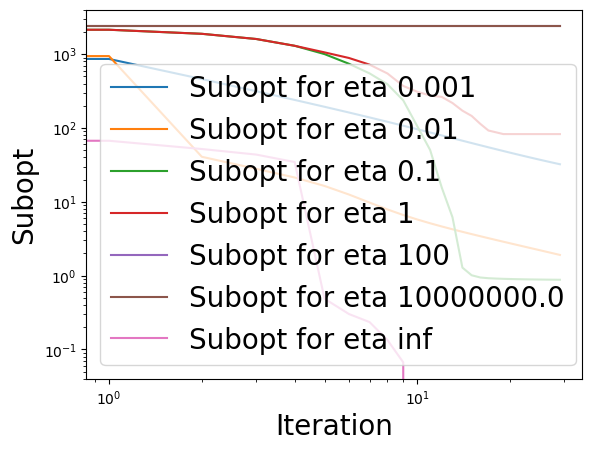

In [6]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

<font color='green'>


Assume the $Q$–values of the current policy $\pi^{t}$ admit a unique maximiser $a_s^\star=\arg\max_a Q^{\pi^t}(s,a)$ for every state $s$.  Because the exponential is strictly increasing, the index that maximises $Q^{\pi^t}(s,\cdot)$ also maximises $\exp(Q^{\pi^t}(s,\cdot))$.  Hence, in the Natural‑Policy‑Gradient update  

$$
\pi^{t+1}(a\mid s)=\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}} ,
$$

the denominator is dominated, as $\eta\to\infty$, by the single term corresponding to $a_s^\star$:

$$
\lim_{\eta\to\infty}\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}
      =\lim_{\eta\to\infty}\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)} .
$$

Now compare the two possible numerators.  When $a=a_s^\star$ the fraction collapses to 1:

$$
\lim_{\eta\to\infty}\frac{\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}}
                               {\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}}=1 .
$$

If instead $a\neq a_s^\star$, the ratio of exponentials is strictly smaller than 1, and raising it to an unbounded $\eta$ drives it to 0:

$$
\frac{e^{Q^{\pi^t}(s,a)}}{e^{Q^{\pi^t}(s,a_s^\star)}}<1
\quad\Longrightarrow\quad
\lim_{\eta\to\infty}
\left(\frac{e^{Q^{\pi^t}(s,a)}}{e^{Q^{\pi^t}(s,a_s^\star)}}\right)^{\eta}=0 ,
$$
so
$$
\lim_{\eta\to\infty}\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}
                               {\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}}=0 .
$$

Collecting the two cases,

$$
\lim_{\eta\to\infty}\pi^{t+1}(a\mid s)=
\begin{cases}
1 & a=a_s^\star ,\\[2pt]
0 & a\neq a_s^\star .
\end{cases}
$$

Thus, with an infinite step size the Natural Policy Gradient produces a policy that, in every state, deterministically chooses the action that maximises $Q^{\pi^t}$. This is precisely the “greedy” policy‑improvement step of classical Policy Iteration, so NPG with $\eta=\infty$ coincides with Policy Iteration.

</font>

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

<font color='green'>

Yes, the plot for $\eta = \infty$ aligns with what we expect from Policy Iteration. It demonstrates rapid convergence in terms of suboptimality, especially when compared to the smaller step sizes. This is in line with the understanding that Natural Policy Gradient (NPG) with an infinite step size essentially mimics the behavior of Policy Iteration. In this setting, the policy is updated to select the best possible action in each state right away, similar to the policy improvement step in PI, which results in fast convergence.

</font>

# Ex 2.1 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [7]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([ np.sum(np.abs(pip[s, :] - pi[s, :])) for s in range(pi.shape[0])])) # TODO
    return variation

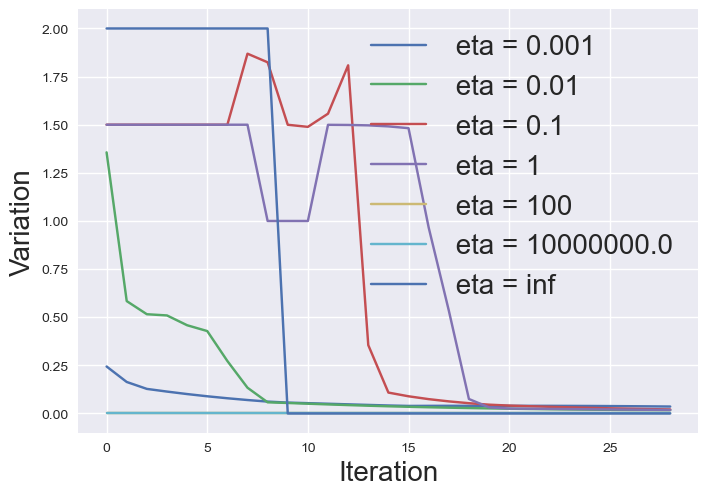

In [8]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

<font color='green'>

The largest changes between consecutive policies occur when the step size $\eta$ is large. This is expected because, as $\eta$ grows (especially approaching infinity), the Natural Policy Gradient update starts to resemble the policy improvement step in Policy Iteration. In such cases, the policy can switch abruptly to assigning full probability to different actions, causing a significant jump in variation, potentially up to 2 in L1 norm. In contrast, smaller values of $\eta$ lead to more incremental updates, resulting in smoother and smaller differences between policies over iterations.

</font>

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

<font color='green'>

Fix any state $s$ and abbreviate $\pi^{t+1}(\cdot\mid s)$ by $P$ and $\pi^{t}(\cdot\mid s)$ by $Q$. Pinsker’s inequality tells us that $\tfrac12\|P-Q\|_1^{2}\le D_{\mathrm{KL}}(P\|Q)$, so the desired $L_{1}$ control reduces to bounding the KL term. Inserting the natural‑policy‑gradient update

$$
\pi^{t+1}(a\mid s)=\frac{\pi^{t}(a\mid s)\,\exp\bigl(\eta Q^{\pi^t}(s,a)\bigr)}
                        {\displaystyle\sum_{a'}\pi^{t}(a'\mid s)\,\exp\bigl(\eta Q^{\pi^t}(s,a')\bigr)}
$$
and denoting the normaliser in the denominator by $Z(s)$, we compute
$$
\begin{aligned}
D_{\mathrm{KL}}\!\bigl(\pi^{t+1}\,\|\,\pi^{t}\bigr)
&=\sum_{a}\pi^{t+1}(a\mid s)\,
      \log\frac{\pi^{t+1}(a\mid s)}{\pi^{t}(a\mid s)} \\[2pt]
&=\sum_{a}\pi^{t+1}(a\mid s)\,
      \log\frac{\pi^{t}(a\mid s)e^{\eta Q^{\pi^t}(s,a)}/Z(s)}{\pi^{t}(a\mid s)} \\[2pt]
&=\sum_{a}\pi^{t+1}(a\mid s)\,
      \bigl[\eta Q^{\pi^t}(s,a)-\log Z(s)\bigr] \[2pt]
&=\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]-\log Z(s).
\end{aligned}
$$
Combining this expression with the Pinsker bound gives
$$
\frac12\bigl\|\pi^{t+1}(\cdot\mid s)-\pi^{t}(\cdot\mid s)\bigr\|_1^{2}
\le
\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]
-\log\!\Bigl(\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}\Bigr),
$$
which is precisely the inequality to be shown.

</font>

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

<font color='green'>


Recall the update rule  
$$
\pi^{t+1}(a\mid s)=\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\displaystyle\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}.
$$
Multiplying this expression by $\exp\!\bigl(-\eta Q^{\pi^t}(s,a)\bigr)$ and summing over $a$ gives  
$$
\begin{aligned}
\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}
&=\sum_{a}\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}\,e^{-\eta Q^{\pi^t}(s,a)}\\[4pt]
&=\frac{\sum_{a}\pi^{t}(a\mid s)}{\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}.
\end{aligned}
$$
Because $\pi^{t}(\cdot\mid s)$ is a probability distribution, the numerator reduces to 1, yielding  
$$

\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}
      =\frac{1}{\displaystyle\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}.
\,
$$
Hence the stated identity holds for every state $s$.

</font>

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

<font color='green'>


Starting from the inequality already obtained in part 1,  
$$
\frac12\bigl\|\pi^{t+1}(s)-\pi^{t}(s)\bigr\|_1^{2}
\;\le\;
\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]
-\log\!\Bigl(\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}\Bigr),
$$
define the normalising constant  
$$
Z(s):=\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}.
$$
Part 2 tells us that  
$$
\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}=\frac1{Z(s)}.
$$
Taking logarithms yields $-\log Z(s)=\log\!\bigl(\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}\bigr)$.  Substituting this expression for $-\log Z(s)$ in the previous bound gives  
$$
\frac12\bigl\|\pi^{t+1}(s)-\pi^{t}(s)\bigr\|_1^{2}
\;\le\;
\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]
+\log\!\Bigl(\sum_{a'}\pi^{t+1}(a'\mid s)\,e^{-\eta Q^{\pi^t}(s,a')}\Bigr),
$$
which is precisely the inequality to be proved.

</font>

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

<font color='green'>

Beginning with the estimate already obtained,  
$$
\frac12\|\pi^{t+1}(s)-\pi^{t}(s)\|_1^{2}
\;\le\;
\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]
+\log\!\Bigl(\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}\Bigr),
$$
denote by $X$ the random variable $Q^{\pi^t}(s,a)$ when $a\sim\pi^{t+1}(\cdot\mid s)$.  Because every action–value lies in the interval $[-\frac1{1-\gamma},\frac1{1-\gamma}]$, we have $a\le X\le b$ almost surely with $a=-\frac1{1-\gamma}$ and $b=\frac1{1-\gamma}$, so $b-a=\frac{2}{1-\gamma}$.  Hoeffding’s lemma, applied with $\lambda=-\eta$, gives  
$$
\mathbb E\bigl[e^{-\eta X}\bigr]
\le
\exp\!\Bigl(-\eta\,\mathbb E[X]+\tfrac{\eta^{2}(b-a)^{2}}{8}\Bigr)
=
\exp\!\Bigl(-\eta\,\mathbb E[X]+\tfrac{\eta^{2}}{2(1-\gamma)^{2}}\Bigr).
$$
The logarithm of the sum inside the bound can therefore be controlled as  
$$
\log\!\Bigl(\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}\Bigr)
=\log\mathbb E\bigl[e^{-\eta X}\bigr]
\le
-\eta\,\mathbb E[X]+\frac{\eta^{2}}{2(1-\gamma)^{2}}.
$$
Substituting this estimate into the initial inequality cancels the linear terms in $\eta\,\mathbb E[X]$ and leaves  
$$
\frac12\|\pi^{t+1}(s)-\pi^{t}(s)\|_1^{2}
\;\le\;
\frac{\eta^{2}}{2(1-\gamma)^{2}},
$$
which is exactly the claimed result.
</font>

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



<font color='green'>

We aim to assess whether the following mismatch coefficient is finite:
$$
\max_\pi \max_{s \in \mathcal{S}} \left| \frac{\lambda^\pi(s)}{\mu(s)} \right|
$$
where $\lambda^\pi(s)$ denotes the **discounted state visitation distribution** under a policy $\pi$, defined as:
$$
\lambda^\pi(s) = (1 - \gamma) \sum_{t=0}^{\infty} \gamma^t \mathbb{P}^\pi(s_t = s)
$$

In our setting, the initial state distribution $\mu$ assigns probability 1 to a single state $s_0$ (the bottom-right corner of the grid), and 0 to all others:
- For the initial state $s_0$, we have $\mu(s_0) = 1$, so the mismatch ratio is well-defined:
  $$
  \left| \frac{\lambda^\pi(s_0)}{\mu(s_0)} \right| = \lambda^\pi(s_0)
  $$
  which is finite.

- However, for any other state $s \ne s_0$, we have $\mu(s) = 0$. If the policy $\pi$ leads to non-zero visitation of such a state ($\lambda^\pi(s) > 0$), then:
  $$
  \left| \frac{\lambda^\pi(s)}{\mu(s)} \right| = \frac{\lambda^\pi(s)}{0}
  $$
  which is undefined and effectively diverges to infinity.

Therefore, since it is possible for $\lambda^\pi(s) > 0$ while $\mu(s) = 0$, the mismatch coefficient is unbounded. This highlights the importance of proper exploration mechanisms (such as OPPO), which mitigate the issues caused by such divergence.

</font>

In the following, we experiment with OPPO with and without bonuses in this environment.

In [9]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [10]:
from copy import deepcopy
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=10000) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        #print(k, "k")
        state = 99  # Initial state
        for h in range(H):
            #NPG Update

            policy[h, state, :] = np.exp(eta * (Q[h, state, :] + bonus[h, state, :] - np.max(Q[h, state, :] + bonus[h, state, :]))) # TODO (unnormalized)
            policy[h, state, :] /= np.sum(policy[h, state, :]) # TODO: normalize
            
            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :]) # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1 # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1 # TODO
            
            estimated_transitions[h,state,a,:] = N_next[h, state, a, :] / (N[h, state, a] + 1) # TODO
            

            # Calculate the UCB bonus
            state = new_state
        
        bonus = bonus = beta * np.sqrt(1. / (N + 1e-10)) #Should be of dimension H x Sx A
        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = gridworld.r + bonus[h] + estimated_transitions[h] @ V_new[h+1]
            Q_new[h] = np.clip(Q_new[h], 0, H - h + 1)
            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = Q_new[h, state] @ policy[h, state] # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [11]:
to_plot = []
betas = [0,1e-5, 1e-4, 1e-3, 1e-1, 1, 10]

for beta in betas:
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

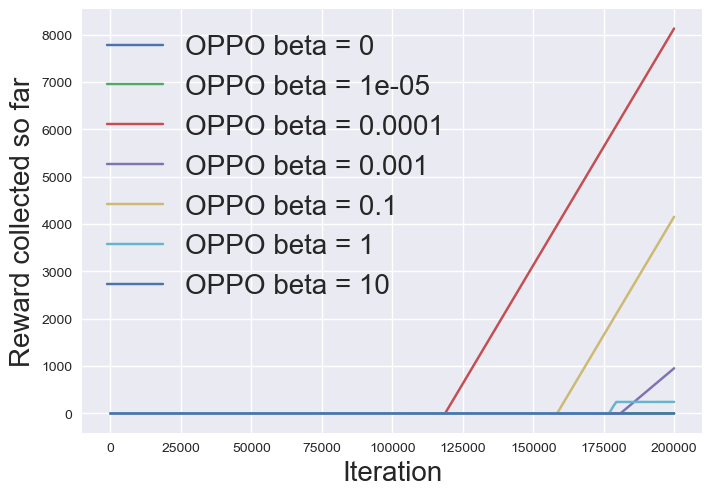

In [12]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=True
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

<font color='green'>

When $\beta = 0$, the exploration bonus is completely removed, which leads to poor performance as shown in the plot — the agent collects almost no reward over time.

### Why does this happen?

**1. No Optimism in the Face of Uncertainty (Slide 28):**  
The exploration bonus plays a critical role in accounting for uncertainty in the estimated transition model. The theoretical bound:
$$
\left| \sum_{s'} \left(\hat{P}_h(s'|s,a) - P_h(s'|s,a)\right) V(s') \right| \leq \text{bonus}_h(s,a)
$$
ensures that the algorithm behaves optimistically with respect to uncertain transitions. With $\beta = 0$, this bonus vanishes — the right-hand side becomes zero — meaning the algorithm falsely assumes perfect knowledge of the environment. As a result, the policy might avoid exploring actions or states where the model is uncertain, leading to suboptimal learning.

**2. Unbounded Mismatch Coefficients (Slide 22):**  
Without exploration, the mismatch coefficient:
$$
\kappa = \left\| \frac{\lambda^\pi}{\mu} \right\|_\infty
$$
can become very large or even unbounded, especially in environments where the initial distribution $\mu$ covers only a small portion of the state space. If the learned policy visits states not covered by $\mu$, $\lambda^\pi(s)/\mu(s)$ becomes infinite, leading to instability in learning and degraded performance.

**3. Degraded Theoretical Guarantee:**  
The performance bound:
$$
\mathbb{E} \left[ \min_{t \leq T} J(\pi^*) - J(\pi_t) \right] \leq \mathcal{O} \left( \sqrt{\kappa \, \epsilon_{\text{stat}}} + \sqrt{\epsilon_{\text{bias}}} \right)
$$
relies on having a bounded $\kappa$. When exploration is disabled ($\beta = 0$), $\kappa$ can grow arbitrarily large, weakening the convergence guarantee and making learning highly data-inefficient.

</font>

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

<font color='green'>
Setting $\beta$ too large leads to poor performance because the exploration bonus $\text{bonus}_h^t(s, a)$ starts to dominate the estimated $Q$-values. When that happens, the agent is incentivized to keep choosing actions that appear attractive due to high uncertainty, even if they're known to be suboptimal. This causes the agent to explore excessively instead of settling on a good policy.

From a theoretical standpoint, the regret bound for OPPO (as shown at the beginning of slide 30) tells us that:
$$
\sum_{t=1}^T \left( V^\star(s_1) - V^{\pi^t}(s_1) \right) \leq \mathcal{O}\left( \sum_{h=1}^H \sum_{t=1}^T \text{bonus}_h^t(s_h^t, a_h^t) \right)
$$
This means the total regret — that is, the difference between the optimal return and what the agent actually gets — is directly tied to the sum of the bonuses. When $\beta$ is too large, these bonuses accumulate quickly, which makes the regret bound loose and allows the agent’s performance to lag behind the optimal policy for much longer.

In short, although exploration is crucial, too much of it can be just as harmful as too little. A large $\beta$ leads the agent to chase uncertainty rather than reward, slowing down learning and resulting in suboptimal behavior, just as we can see in the plot for $\beta = 10$.
</font>

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [13]:
# TODO: you may need to run this to make sure to have the correct versions
%pip install gym==0.25.2
%pip install gym-notices==0.0.8
%pip install numpy==1.23.5


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [16]:
env = gym.make('CartPole-v0')
env.seed(0)

/opt/miniconda3/envs/RL/lib/python3.10/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/opt/miniconda3/envs/RL/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/miniconda3/envs/RL/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/miniconda3/envs/RL/lib/python3.10/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be remove

[0]

In [17]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [18]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

<font color='green'>

- **Baseline 1 – Energy-Based Baseline**:
    This baseline estimates the total energy of the system using potential and kinetic energy from both the cart and the pole. The idea is that when the system is balanced and stable, its energy is low. By subtracting this (negative) energy value from the return, we help the agent focus on keeping the pole upright with minimal movement. This led to faster convergence and more stable performance overall, especially in the later episodes.

- **Baseline 2 – Position-Angle Penalty**:
    This one is a simple function based on the absolute values of the cart’s position and the pole’s angle. We gave more weight to the pole angle since it’s more critical for keeping balance. It doesn't try to model the full dynamics like energy does, but it was surprisingly effective. It gave the agent a strong early learning signal and helped improve performance much quicker than using no baseline at all.

</font>

In [19]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
    x, x_dot, theta, theta_dot = state
    pot = 1.2 * (1.0 - np.cos(theta))
    kin_cart = 0.4 * x_dot**2
    kin_pole = 0.4 * theta_dot**2
    energy = pot + kin_cart + kin_pole
    value = -(energy)
    return value

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
    x, _, theta, _ = state
    value = -15.0 * abs(x) - 45.0 * abs(theta)
    return value

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores


In [26]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
print("================ NO BASELINE ==================")
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)


================ NO BASELINE ==================
Episode 100	Average Score: 43.58
Episode 200	Average Score: 72.41
Episode 300	Average Score: 152.60
Episode 400	Average Score: 166.08
Episode 500	Average Score: 186.52
Episode 600	Average Score: 185.95
Episode 700	Average Score: 166.88
Episode 800	Average Score: 186.72
Episode 900	Average Score: 192.77
Episode 1000	Average Score: 193.12
Episode 1100	Average Score: 147.22
Episode 1200	Average Score: 116.66
Episode 1300	Average Score: 138.28
Episode 1400	Average Score: 146.56
Episode 1500	Average Score: 198.25
Episode 1600	Average Score: 199.79
Episode 1700	Average Score: 198.69
Episode 1800	Average Score: 169.48
Episode 1900	Average Score: 158.21


In [27]:

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
print("================ BASELINE 1 ==================")
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)


================ BASELINE 1 ==================
Episode 100	Average Score: 49.67
Episode 200	Average Score: 43.71
Episode 300	Average Score: 89.49
Episode 400	Average Score: 150.62
Episode 500	Average Score: 171.71
Episode 600	Average Score: 142.14
Episode 700	Average Score: 182.55
Episode 800	Average Score: 121.96
Episode 900	Average Score: 107.46
Episode 1000	Average Score: 103.33
Episode 1100	Average Score: 117.31
Episode 1200	Average Score: 106.04
Episode 1300	Average Score: 106.00
Episode 1400	Average Score: 113.66
Episode 1500	Average Score: 194.04
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 137.71
Episode 1800	Average Score: 134.70
Episode 1900	Average Score: 173.47


In [28]:

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
print("================ BASELINE 2 ==================")
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



================ BASELINE 2 ==================
Episode 100	Average Score: 38.87
Episode 200	Average Score: 76.27
Episode 300	Average Score: 136.74
Episode 400	Average Score: 197.19
Episode 500	Average Score: 197.83
Episode 600	Average Score: 199.12
Episode 700	Average Score: 200.00
Episode 800	Average Score: 183.75
Episode 900	Average Score: 195.19
Episode 1000	Average Score: 104.23
Episode 1100	Average Score: 97.29
Episode 1200	Average Score: 108.18
Episode 1300	Average Score: 103.64
Episode 1400	Average Score: 118.25
Episode 1500	Average Score: 116.29
Episode 1600	Average Score: 147.54
Episode 1700	Average Score: 198.19
Episode 1800	Average Score: 157.16
Episode 1900	Average Score: 114.88


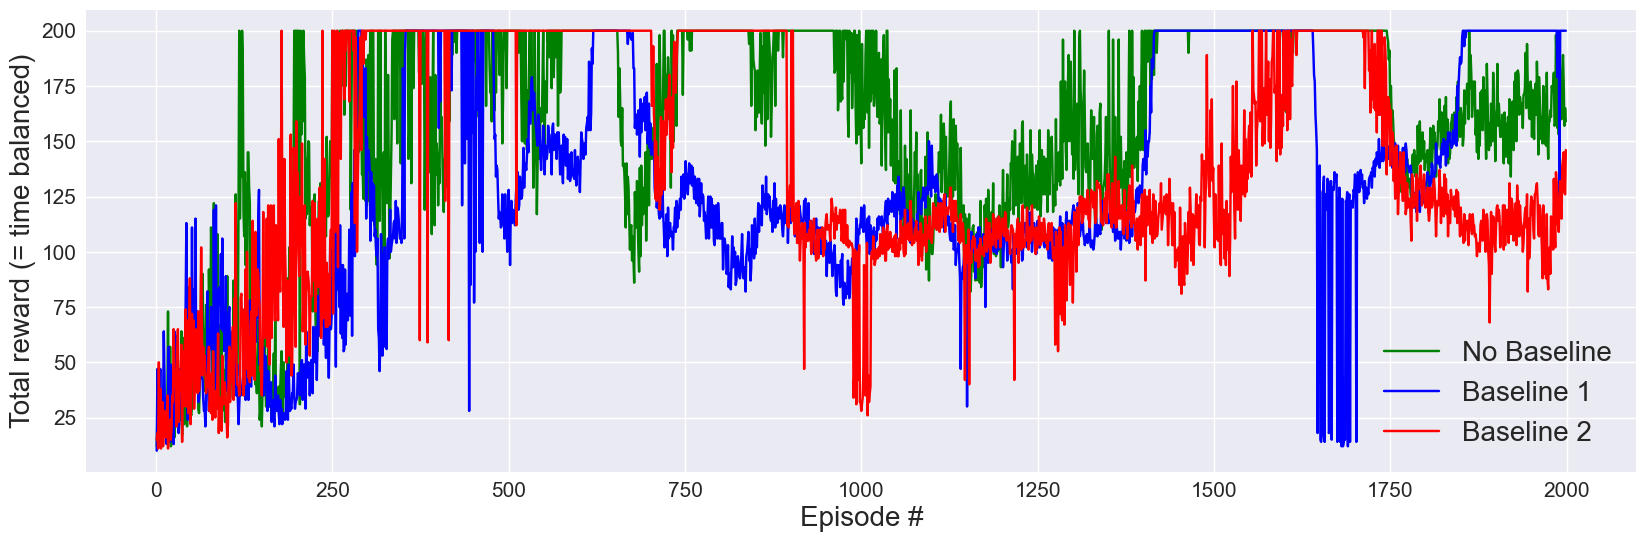

In [29]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:
$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$

<font color='green'>

We consider a Gaussian policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathbb{R}^d$ and covariance matrix $\Sigma$. The objective is:

$$
J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\tau \sim \pi_{\mu, \Sigma}} \left[ \sum_{t=0}^{\infty} \gamma^t r(s_t, a_t) \,\big|\, s_0 \right]
$$

The policy is parameterized as:
$$
\pi_{\mu, \Sigma}(a|s) = \frac{1}{\sqrt{2\pi} \sigma(s)} \exp\left(-\frac{(a - \mu(s))^2}{2 \sigma(s)^2}\right)
$$

Then, the gradients of the expected return with respect to the mean and covariance parameters are:

- **Gradient w.r.t. the mean**:
$$
\nabla_\mu J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\tau \sim \pi_{\mu, \Sigma}} \left[ \sum_{t=0}^{\infty} \gamma^t Q^{\pi_{\mu, \Sigma}}(s_t, a_t) \, \Sigma^{-1}(s_t) (a_t - \mu(s_t)) \right]
$$

In the case of a diagonal $\Sigma$, this simplifies to:
$$
\nabla_\mu J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\tau} \left[ \sum_{t=0}^\infty \gamma^t Q(s_t, a_t) \cdot \frac{a_t - \mu(s_t)}{\sigma^2(s_t)} \right]
$$

- **Gradient w.r.t. the covariance**:
$$
\nabla_\Sigma J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\tau} \left[ \sum_{t=0}^{\infty} \gamma^t Q(s_t, a_t) \cdot \frac{1}{2} \left( \Sigma^{-1}(s_t)(a_t - \mu(s_t))(a_t - \mu(s_t))^T \Sigma^{-1}(s_t) - \Sigma^{-1}(s_t) \right) \right]
$$

Again, for a diagonal $\Sigma$, this becomes:
$$
\nabla_\Sigma J(\pi_{\mu, \Sigma}) = \mathbb{E}_{\tau} \left[ \sum_{t=0}^{\infty} \gamma^t Q(s_t, a_t) \cdot \frac{1}{2} \left( \frac{(a_t - \mu(s_t))^2 - \sigma^2(s_t)}{\sigma^4(s_t)} \right) \right]
$$

</font>


***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SA \log( T H)$$


<font color='green'>


We want to prove:
$$
\sum_{t=1}^T \sum_{h=1}^H \frac{1}{N_h^t(s_h^t, a_h^t) + 1} \leq SA \log(TH)
$$

Let $V_{s,a}$ denote the total number of times a state-action pair $(s,a)$ has been visited across all episodes and steps. Then:

$$
\sum_{t=1}^T \sum_{h=1}^H \frac{1}{N_h^t(s_h^t, a_h^t)+1}
= \sum_{(s,a)} \sum_{k=1}^{V_{s,a}} \frac{1}{k+1}
= \sum_{(s,a)} \sum_{k=2}^{V_{s,a}+1} \frac{1}{k}
$$

This is a harmonic sum, which can be upper bounded by a logarithm:
$$
\sum_{k=2}^{V_{s,a}+1} \frac{1}{k} \leq \log(V_{s,a}+1)
\Rightarrow \sum_{(s,a)} \log(V_{s,a} + 1)
$$

Since each $(s,a)$ can be visited at most $TH$ times:
$$
\sum_{(s,a)} \log(TH + 1) \leq SA \log(TH + 1) \leq SA \log(TH)
$$

So, the total sum is bounded as:
$$
\sum_{t=1}^T \sum_{h=1}^H \frac{1}{N_h^t(s_h^t, a_h^t)+1} \leq SA \log(TH)
$$

</font>


***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq \sqrt{ H^3 SA T \log( T H)}$$

<font color='green'>

Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq \sqrt{ H^3 SA T \log( T H)}$$

Let's start by writing out the bonus:

$$
\sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) = \sum^T_{t=1} \sum^H_{h=1} \frac{H}{\sqrt{N_h^t(s_h^t,a_h^t)}}
$$

From here, notice that:

$$
(\sum^T_{t=1} \sum^H_{h=1} \frac{H}{\sqrt{N_h^t(s_h^t,a_h^t)}})^2 \leq \sum^T_{t=1} \sum^H_{h=1} H^2 * \sum^T_{t=1} \sum^H_{h=1} (\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)}})^2
$$

due to the Cauchy-Schwarz inequality. From there, we get:

$$
\sum^T_{t=1} \sum^H_{h=1} \frac{H}{\sqrt{N_h^t(s_h^t,a_h^t)}} \leq \sqrt{\sum^T_{t=1} \sum^H_{h=1} H^2} * \sqrt{\sum^T_{t=1} \sum^H_{h=1} (\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)}})^2}
$$

$$
\sum^T_{t=1} \sum^H_{h=1} \frac{H}{\sqrt{N_h^t(s_h^t,a_h^t)}} \leq \sqrt{TH^3} * \sqrt{\sum^T_{t=1} \sum^H_{h=1} (\frac{1}{N_h^t(s_h^t,a_h^t)})}
$$

</font>